In [3]:
# 1. IMPORTS & SETUP
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                             calinski_harabasz_score, adjusted_rand_score)
warnings.filterwarnings("ignore")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 30)
os.makedirs("EDA_Plots", exist_ok=True)
DATA_PATH = "olist_merged_dataset.csv"
print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
# 2. LOAD & PREPARE DATA
df = pd.read_csv(DATA_PATH)
required_cols = [
    "customer_unique_id", "order_id", "price", "freight_value",
    "order_status", "order_purchase_timestamp",
    "order_delivered_customer_date", "order_estimated_delivery_date",
    "order_item_id"
]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

for col in ["order_purchase_timestamp", "order_delivered_customer_date",
            "order_estimated_delivery_date"]:
    df[col] = pd.to_datetime(df[col], errors="coerce")
print("Raw shape:", df.shape)

df = df.dropna(subset=["customer_unique_id", "order_id", "price", "freight_value"])
df = df[(df["price"] >= 0) & (df["freight_value"] >= 0)]
# Only delivered orders: delivery-time features need a real delivery date,
# and cancelled / unavailable orders are not real purchases.
df = df[(df["order_status"] == "delivered") & df["order_delivered_customer_date"].notna() &
        df["order_estimated_delivery_date"].notna() & df["order_purchase_timestamp"].notna()].copy()
print("After cleaning (delivered orders only):", df.shape)

df["deliv_days"] = (df["order_delivered_customer_date"] - df["order_purchase_timestamp"]).dt.total_seconds() / 86400
df["delay_days"] = (df["order_delivered_customer_date"] - df["order_estimated_delivery_date"]).dt.total_seconds() / 86400

Raw shape: (113425, 18)
After cleaning (delivered orders only): (110189, 18)


In [5]:
# 3. CUSTOMER-LEVEL FEATURES (order level first, then customer level)
ref_date = df["order_purchase_timestamp"].max() + pd.Timedelta(days=1)

orders = df.groupby(["customer_unique_id", "order_id"]).agg(
    order_value=("price", "sum"),
    order_freight=("freight_value", "sum"),
    items=("order_item_id", "count"),
    purchase=("order_purchase_timestamp", "first"),
    deliv_days=("deliv_days", "first"),
    delay_days=("delay_days", "first"),
).reset_index()

cust = orders.groupby("customer_unique_id").agg(
    Orders=("order_id", "nunique"),
    Total_Spending=("order_value", "sum"),
    Total_Freight=("order_freight", "sum"),
    Avg_Items_Per_Order=("items", "mean"),
    Last_Purchase=("purchase", "max"),
    Avg_Delivery_Days=("deliv_days", "mean"),
    Avg_Delivery_Delay=("delay_days", "mean"),
).reset_index()

cust["Recency_Days"] = (ref_date - cust["Last_Purchase"]).dt.days
cust["Is_Repeat"] = (cust["Orders"] > 1).astype(int)
cust["Freight_Share"] = cust["Total_Freight"] / (cust["Total_Spending"] + cust["Total_Freight"])
cust = cust.drop(columns="Last_Purchase")

print("Customers:", len(cust))
print("Repeat customers: %.1f%%" % (cust["Is_Repeat"].mean() * 100))

Customers: 93350
Repeat customers: 3.0%


                       count    mean     std     min     25%     50%     75%       max
Recency_Days         93350.0  237.95  152.59    1.00  114.00  219.00  346.00    714.00
Is_Repeat            93350.0    0.03    0.17    0.00    0.00    0.00    0.00      1.00
Total_Spending       93350.0  141.62  215.70    0.85   47.65   89.70  154.70  13440.00
Avg_Items_Per_Order  93350.0    1.14    0.53    1.00    1.00    1.00    1.00     21.00
Freight_Share        93350.0    0.21    0.12    0.00    0.12    0.18    0.27      0.96
Avg_Delivery_Days    93350.0   12.57    9.55    0.53    6.79   10.23   15.72    209.63
Avg_Delivery_Delay   93350.0  -11.15   10.14 -146.02  -16.23  -11.75   -6.39    188.98


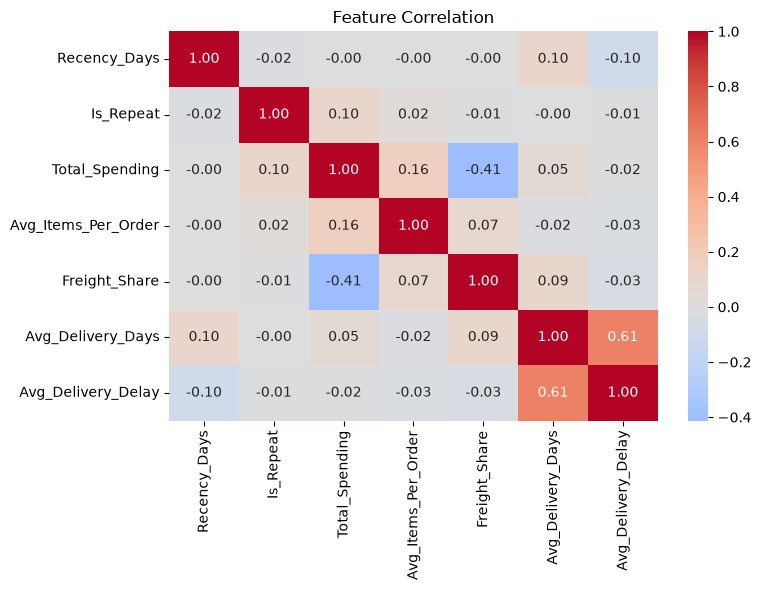

In [6]:
# 4. FEATURE SELECTION + CORRELATION CHECK
features = ["Recency_Days", "Is_Repeat", "Total_Spending", "Avg_Items_Per_Order",
            "Freight_Share", "Avg_Delivery_Days", "Avg_Delivery_Delay"]
print(cust[features].describe().T.round(2))

plt.figure(figsize=(8, 6))
sns.heatmap(cust[features].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature Correlation")
plt.tight_layout(); plt.savefig("EDA_Plots/feature_correlation.png", dpi=150); plt.show()

In [7]:
# 5. SKEW HANDLING (log + winsorize at 1st/99th percentile)
X = cust[features].copy()

X["Total_Spending"] = np.log1p(X["Total_Spending"].clip(lower=0))
X["Avg_Delivery_Days"] = np.log1p(X["Avg_Delivery_Days"].clip(lower=0))

for col in ["Total_Spending", "Avg_Items_Per_Order", "Freight_Share",
            "Avg_Delivery_Days", "Avg_Delivery_Delay"]:
    lo, hi = X[col].quantile([0.01, 0.99])
    X[col] = X[col].clip(lo, hi)

valid = X.replace([np.inf, -np.inf], np.nan).notna().all(axis=1)
X = X.loc[valid].copy()
cust = cust.loc[valid].copy().reset_index(drop=True)
X = X.reset_index(drop=True)

print("Rows used for clustering:", len(X))
print("Skewness after transform:")
print(X.skew().round(2))


Rows used for clustering: 93350
Skewness after transform:
Recency_Days           0.45
Is_Repeat              5.51
Total_Spending         0.22
Avg_Items_Per_Order    3.38
Freight_Share          0.95
Avg_Delivery_Days     -0.02
Avg_Delivery_Delay     0.39
dtype: float64


In [8]:
# 6. SCALING
X_scaled = StandardScaler().fit_transform(X)
print("Scaled shape:", X_scaled.shape)

Scaled shape: (93350, 7)


      Inertia  Silhouette  Davies_Bouldin  Calinski_Harabasz
K                                                           
2  546773.656       0.175           1.943          18212.446
3  454922.140       0.204           1.458          20368.446
4  381287.163       0.233           1.308          22210.350
5  325896.421       0.223           1.227          23455.008
6  285924.394       0.225           1.205          23996.909
7  262145.398       0.214           1.214          23222.337
8  247521.209       0.207           1.225          21868.506


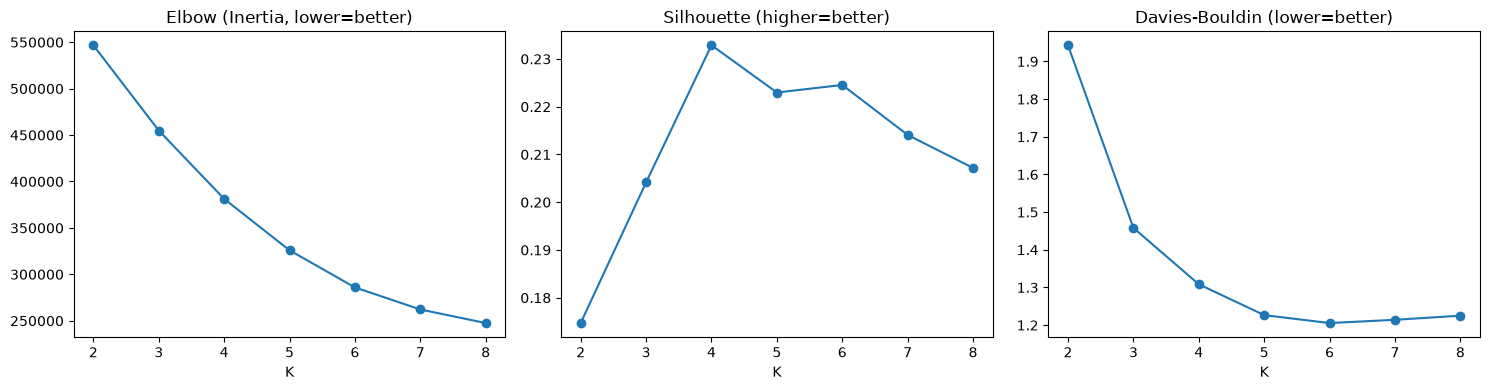

In [10]:
# 7. CHOOSING K: elbow + silhouette + Davies-Bouldin + Calinski-Harabasz
K_values = list(range(2, min(8, len(X_scaled) - 1) + 1))
if len(K_values) == 0:
    raise ValueError("Not enough customers for KMeans clustering.")
rs = np.random.RandomState(42)
idx = rs.choice(len(X_scaled), min(10000, len(X_scaled)), replace=False)   # sample only for silhouette (speed)
rows = []
for k in K_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
    rows.append({"K": k, "Inertia": km.inertia_,
                 "Silhouette": silhouette_score(X_scaled[idx], km.labels_[idx]),
                 "Davies_Bouldin": davies_bouldin_score(X_scaled, km.labels_),
                 "Calinski_Harabasz": calinski_harabasz_score(X_scaled, km.labels_)})
k_table = pd.DataFrame(rows).set_index("K")
print(k_table.round(3))

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(K_values, k_table["Inertia"], marker="o"); ax[0].set_title("Elbow (Inertia, lower=better)")
ax[1].plot(K_values, k_table["Silhouette"], marker="o"); ax[1].set_title("Silhouette (higher=better)")
ax[2].plot(K_values, k_table["Davies_Bouldin"], marker="o"); ax[2].set_title("Davies-Bouldin (lower=better)")
for a in ax: a.set_xlabel("K")
plt.tight_layout(); plt.savefig("EDA_Plots/choosing_k.png", dpi=150); plt.show()

In [11]:
# 8. FINAL K
# Silhouette peaks at K=4 (0.233) but K=5 is almost identical (0.223) and is better on
# Davies-Bouldin / Calinski-Harabasz. K=5 also separates a business-relevant
# "late delivery" segment that K=4 merges into other groups. So K=5 is used.
FINAL_K = min(5, len(X_scaled))
if FINAL_K < 2:
    raise ValueError("At least 2 customers are required for clustering.")
kmeans = KMeans(n_clusters=FINAL_K, random_state=42, n_init=10)
cust["Cluster"] = kmeans.fit_predict(X_scaled)

# stability: re-run with other seeds, ARI close to 1 = same clusters every time
aris = [adjusted_rand_score(cust["Cluster"], KMeans(FINAL_K, random_state=s, n_init=10).fit_predict(X_scaled))
        for s in (1, 2, 3, 4)]
print("Stability (ARI vs other seeds):", [round(a, 3) for a in aris])
print("Final silhouette (10k sample): %.4f" % silhouette_score(X_scaled[idx], cust["Cluster"].values[idx]))

Stability (ARI vs other seeds): [0.999, 0.991, 0.997, 0.981]
Final silhouette (10k sample): 0.2230


In [12]:
# 9. CLUSTER PROFILE (real, un-transformed values)
profile = cust.groupby("Cluster").agg(
    Customers=("customer_unique_id", "count"),
    Recency_Days=("Recency_Days", "mean"),
    Repeat_Rate=("Is_Repeat", "mean"),
    Avg_Spending=("Total_Spending", "mean"),
    Items_Per_Order=("Avg_Items_Per_Order", "mean"),
    Freight_Share=("Freight_Share", "mean"),
    Delivery_Days=("Avg_Delivery_Days", "mean"),
    Delivery_Delay_Days=("Avg_Delivery_Delay", "mean"),
)
profile["Share_%"] = profile["Customers"] / len(cust) * 100

# readable names, assigned by rules from the profile (so they stay correct if IDs change)
names, left = {}, set(profile.index)
def pick(series, label, largest=True):
    cl = series[list(left)].idxmax() if largest else series[list(left)].idxmin()
    names[cl] = label; left.remove(cl)
pick(profile["Repeat_Rate"], "Repeat customers")
pick(profile["Items_Per_Order"], "Multi-item basket buyers")
pick(profile["Delivery_Days"], "Late-delivery customers")
pick(profile["Avg_Spending"], "Low-value, freight-heavy", largest=False)
for cl in left: names[cl] = "Fast-delivery, mid-value buyers"
profile.insert(0, "Segment", profile.index.map(names))
cust["Segment"] = cust["Cluster"].map(names)
print(profile.round(2))

                                 Segment  Customers  Recency_Days  Repeat_Rate  Avg_Spending  Items_Per_Order  Freight_Share  Delivery_Days  Delivery_Delay_Days  Share_%
Cluster                                                                                                                                                                  
0                Late-delivery customers      16207        245.22          0.0        149.15             1.01           0.18          25.49                 0.72    17.36
1                       Repeat customers       2801        220.29          1.0        260.05             1.21           0.20          12.34               -11.90     3.00
2               Low-value, freight-heavy      25350        237.30          0.0         35.36             1.01           0.35          10.77               -13.01    27.16
3        Fast-delivery, mid-value buyers      40649        236.61          0.0        182.76             1.00           0.13           8.86           

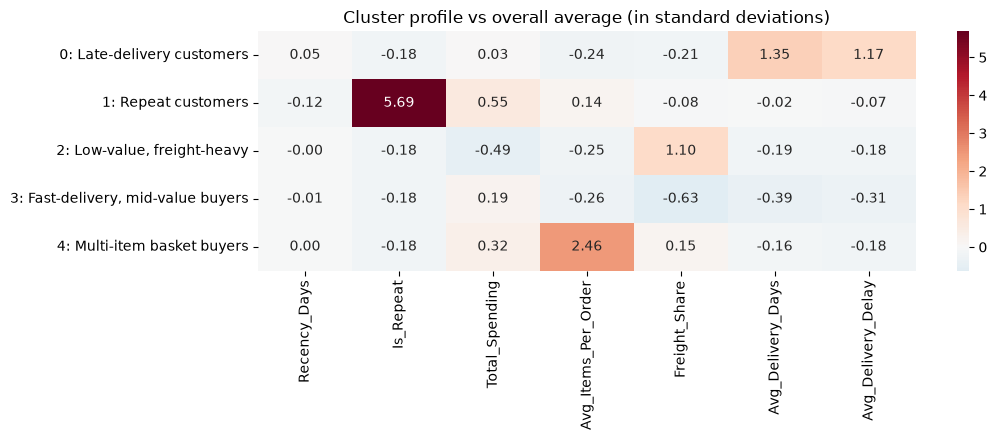

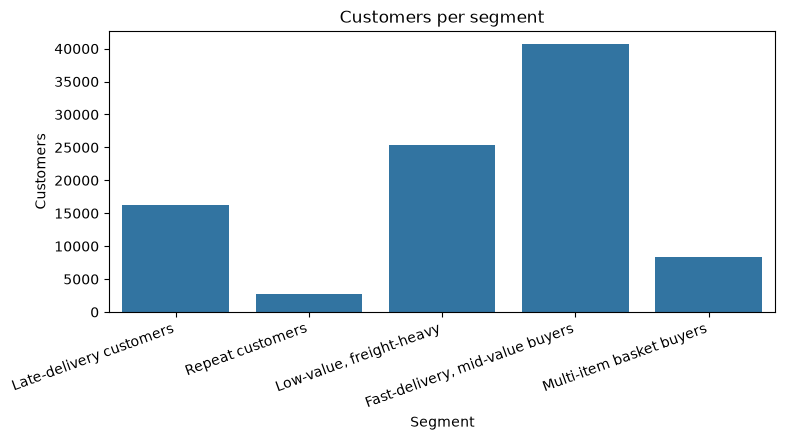

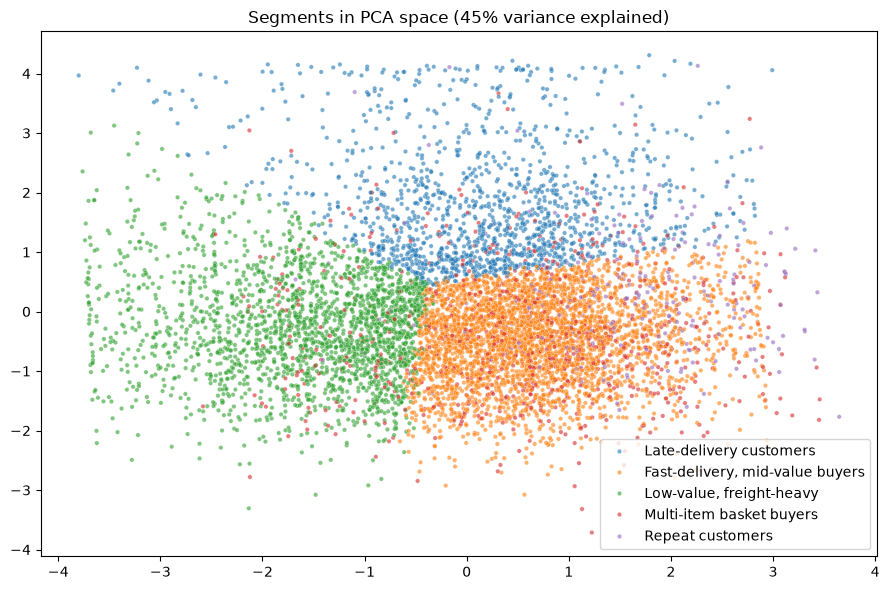

In [13]:
# 10. PLOTS
# (a) heatmap: how far each cluster is from the overall average (in standard deviations)
z = (cust.groupby("Cluster")[features].mean() - cust[features].mean()) / cust[features].std()
z.index = [f"{i}: {names[i]}" for i in z.index]
plt.figure(figsize=(11, 4.5))
sns.heatmap(z, annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Cluster profile vs overall average (in standard deviations)")
plt.tight_layout(); plt.savefig("EDA_Plots/cluster_profile_heatmap.png", dpi=150); plt.show()

# (b) cluster sizes
plt.figure(figsize=(8, 4.5))
sns.barplot(x=profile["Segment"], y=profile["Customers"])
plt.xticks(rotation=20, ha="right"); plt.title("Customers per segment")
plt.tight_layout(); plt.savefig("EDA_Plots/cluster_size.png", dpi=150); plt.show()

# (c) PCA 2-D view (for visualization only; clustering used all 7 features)
pca = PCA(n_components=2, random_state=42)
pts = pca.fit_transform(X_scaled)
samp = rs.choice(len(pts), min(8000, len(pts)), replace=False)
plt.figure(figsize=(9, 6))
sns.scatterplot(x=pts[samp, 0], y=pts[samp, 1], hue=cust["Segment"].values[samp], s=10, alpha=0.6)
plt.title("Segments in PCA space (%.0f%% variance explained)" % (pca.explained_variance_ratio_.sum() * 100))
plt.tight_layout(); plt.savefig("EDA_Plots/pca_segments.png", dpi=150); plt.show()

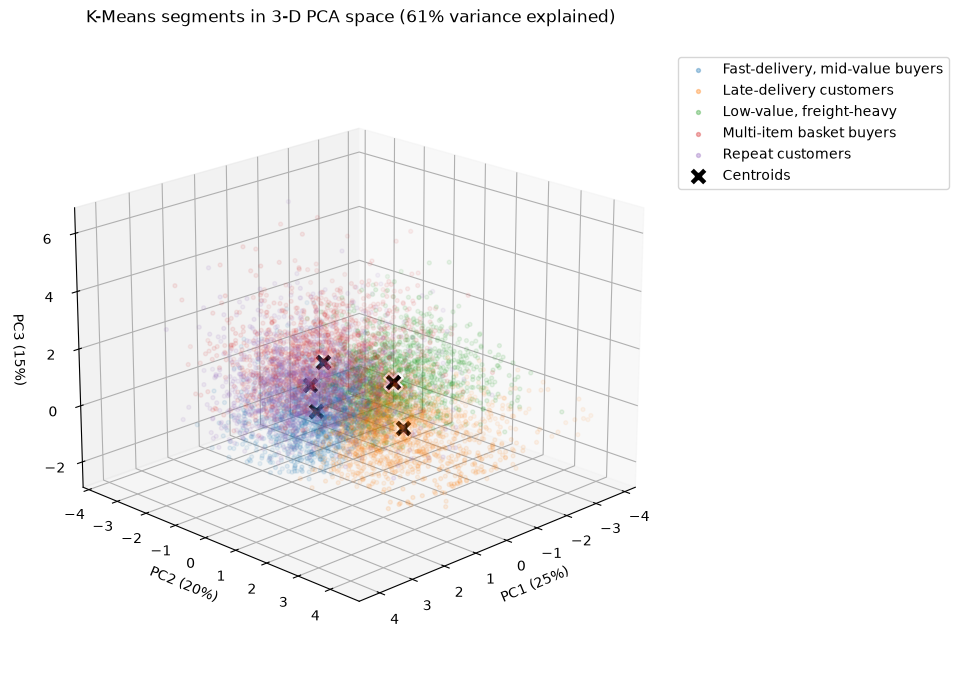

In [19]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

pca3 = PCA(n_components=3, random_state=42)
pts3 = pca3.fit_transform(X_scaled)
cent3 = pca3.transform(kmeans.cluster_centers_)

# har segment se barabar points, taake chhote segments bhi dikhein
per_seg = 1600
samp3 = np.concatenate([
    rs.choice(np.where(cust["Segment"].values == s)[0],
              min(per_seg, (cust["Segment"].values == s).sum()), replace=False)
    for s in cust["Segment"].unique()
])
seg_s = cust["Segment"].values[samp3]

fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection="3d")
for seg in sorted(cust["Segment"].unique()):
    m = seg_s == seg
    ax.scatter(pts3[samp3][m, 0], pts3[samp3][m, 1], pts3[samp3][m, 2],
               s=8, alpha=0.35, label=seg)

ax.scatter(cent3[:, 0], cent3[:, 1], cent3[:, 2], c="black", marker="X",
           s=180, edgecolor="white", linewidth=1.5, depthshade=False,
           label="Centroids", zorder=10)

ev = pca3.explained_variance_ratio_
ax.set_xlabel(f"PC1 ({ev[0]*100:.0f}%)")
ax.set_ylabel(f"PC2 ({ev[1]*100:.0f}%)")
ax.set_zlabel(f"PC3 ({ev[2]*100:.0f}%)")
ax.set_title("K-Means segments in 3-D PCA space (%.0f%% variance explained)" % (ev.sum() * 100), pad=20)
ax.view_init(elev=20, azim=45)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), markerscale=1)
plt.savefig("EDA_Plots/pca_segments_3d.png", dpi=150, bbox_inches="tight"); plt.show()

In [14]:
# 11. SAVE RESULTS
cust.to_csv("customer_segments.csv", index=False)
profile.round(2).to_csv("cluster_profile.csv")
print("Saved: customer_segments.csv, cluster_profile.csv")

Saved: customer_segments.csv, cluster_profile.csv
